# Experiment 003 — CNN-LSTM Hybrid

**Date**: July 2026  
**Author**: Anurag Sharma  
**Project**: Project 07 — LUCID: Reality?

## Hypothesis
A CNN-LSTM hybrid that extracts spatial frequency features 
with CNN then models temporal transitions with LSTM will 
outperform both:
- Experiment 001: SleepLSTM (76.85%, REM recall 0.84)
- Experiment 002: CNN spectrograms (71.67%, REM recall 0.66)

## Architecture idea
Raw EEG epoch (3000 samples)
    ↓ split into 10 windows of 300 samples
CNN extracts features from each window
    ↓ sequence of 10 feature vectors
LSTM models temporal transitions between windows
    ↓
Sleep stage classification (5 classes)

## Why this should work
- CNN sees LOCAL frequency patterns in each window
- LSTM sees HOW those patterns CHANGE over 30 seconds
- Together: spatial + temporal understanding

In [1]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report,
                              confusion_matrix)
from datetime import datetime

# ── Paths ─────────────────────────────────────────────────
PROJECT_ROOT  = r"C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline"
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR    = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR     = os.path.join(PROJECT_ROOT, "plots")
LOGS_DIR      = os.path.join(PROJECT_ROOT, "logs")
SRC_DIR       = os.path.join(PROJECT_ROOT, "src")

sys.path.append(SRC_DIR)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)
os.makedirs(LOGS_DIR,   exist_ok=True)

# Constants
STAGE_NAMES  = ['Wake', 'N1', 'N2', 'N3', 'REM']
STAGE_COLORS = {
    0:'#E24B4A', 1:'#BA7517',
    2:'#185FA5', 3:'#534AB7', 4:'#1D9E75'
}

# Baselines to beat
BASELINE = {
    'exp001_lstm': {'accuracy': 0.7685, 'rem_recall': 0.84},
    'exp002_cnn':  {'accuracy': 0.7167, 'rem_recall': 0.66},
}

# ── Load data ──────────────────────────────────────────────
epochs_all = np.load(
    os.path.join(PROCESSED_DIR, "epochs_all.npy"))
labels_all = np.load(
    os.path.join(PROCESSED_DIR, "labels_all.npy"))

print(f"Data loaded")
print(f"   Epochs: {epochs_all.shape}")
print(f"   Labels: {labels_all.shape}")
print(f"\nBaselines:")
for name, metrics in BASELINE.items():
    print(f"  {name}: acc={metrics['accuracy']:.4f}, "
          f"REM recall={metrics['rem_recall']:.4f}")

Data loaded
   Epochs: (18226, 3000)
   Labels: (18226,)

Baselines:
  exp001_lstm: acc=0.7685, REM recall=0.8400
  exp002_cnn: acc=0.7167, REM recall=0.6600


## 1. Model Architecture — CNN-LSTM Hybrid

In [2]:
class CNNLSTMSleepClassifier(nn.Module):
    """
    CNN-LSTM Hybrid for EEG sleep stage classification.
    
    Each 30s epoch is split into N windows.
    CNN extracts features from each window independently.
    LSTM models the temporal sequence of CNN features.
    """

    def __init__(self,
                 n_windows=10,       # split epoch into 10 windows
                 window_size=300,    # 300 samples per window (3s)
                 cnn_out_dim=128,    # CNN output features
                 lstm_hidden=128,    # LSTM hidden size
                 lstm_layers=2,      # stacked LSTM
                 n_classes=5,        # sleep stages
                 dropout=0.3):
        super().__init__()

        self.n_windows   = n_windows
        self.window_size = window_size

        # ── CNN — feature extractor per window ────────────
        # Input:  (batch, 1, window_size)
        # Output: (batch, cnn_out_dim)
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Global average pool → fixed size output
            nn.AdaptiveAvgPool1d(cnn_out_dim // 128)
        )

        # CNN output size after pooling
        cnn_flat_dim = 128 * (cnn_out_dim // 128)

        # ── LSTM — temporal modelling ──────────────────────
        # Input:  (batch, n_windows, cnn_flat_dim)
        # Output: (batch, n_windows, lstm_hidden * 2)
        self.lstm = nn.LSTM(
            input_size=cnn_flat_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True    # forward + backward
        )

        # ── Classifier ────────────────────────────────────
        lstm_out_dim = lstm_hidden * 2   # ×2 bidirectional

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        """
        x: (batch, 3000) — raw EEG epoch
        """
        batch = x.shape[0]

        # ── Step 1: Splitting epoch into windows ──────────────
        # (batch, 3000) → (batch, n_windows, window_size)
        x = x.reshape(batch, self.n_windows, self.window_size)

        # ── Step 2: CNN on each window ────────────────────
        cnn_features = []
        for t in range(self.n_windows):
            window  = x[:, t, :].unsqueeze(1)  # (B, 1, 300)
            feature = self.cnn(window)           # (B, 128, K)
            feature = feature.reshape(batch, -1) # (B, 128*K)
            cnn_features.append(feature)

        # Stack: (batch, n_windows, cnn_flat_dim)
        sequence = torch.stack(cnn_features, dim=1)

        # ── Step 3: LSTM over window sequence ─────────────
        lstm_out, _ = self.lstm(sequence)

        # Taking last timestep — summary of full epoch
        last = lstm_out[:, -1, :]   # (batch, lstm_hidden*2)

        # ── Step 4: Classify ──────────────────────────────
        return self.classifier(last)


# ── Instantiate and inspect ───────────────────────────────
model_hybrid = CNNLSTMSleepClassifier(
    n_windows=10,
    window_size=300,
    cnn_out_dim=128,
    lstm_hidden=128,
    lstm_layers=2,
    n_classes=5,
    dropout=0.3
)

total     = sum(p.numel() for p in model_hybrid.parameters())
trainable = sum(p.numel() for p in model_hybrid.parameters()
                if p.requires_grad)

print("=== CNN-LSTM Hybrid Architecture ===\n")
print(model_hybrid)
print(f"\nTotal parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")

# ── Verifying shapes with a dummy forward pass ───────────────
dummy = torch.randn(4, 3000)   # batch of 4 epochs
out   = model_hybrid(dummy)
print(f"\nDummy forward pass:")
print(f"  Input:  {dummy.shape}  (batch=4, samples=3000)")
print(f"  Output: {out.shape}   (batch=4, classes=5)")
print(f"   Shapes correct" if out.shape == (4, 5)
      else "   Shape error")

=== CNN-LSTM Hybrid Architecture ===

CNNLSTMSleepClassifier(
  (cnn): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_fe

In [3]:
class RawEEGDataset(Dataset):
    """Simple dataset for raw EEG epochs."""
    def __init__(self, epochs, labels):
        # Normalise per epoch
        mean = epochs.mean(axis=1, keepdims=True)
        std  = epochs.std(axis=1,  keepdims=True) + 1e-8
        self.epochs = ((epochs - mean) / std).astype(np.float32)
        self.labels = labels.astype(np.int64)

    def __len__(self):
        return len(self.epochs)

    def __getitem__(self, idx):
        return (torch.FloatTensor(self.epochs[idx]),
                self.labels[idx])


# ── Split ─────────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    epochs_all, labels_all,
    test_size=0.2,
    random_state=42,
    stratify=labels_all
)

train_ds = RawEEGDataset(X_tr, y_tr)
test_ds  = RawEEGDataset(X_te, y_te)

train_loader = DataLoader(
    train_ds, batch_size=64,
    shuffle=True, num_workers=0
)
test_loader = DataLoader(
    test_ds, batch_size=128,
    shuffle=False, num_workers=0
)

print(f"Train: {len(train_ds):,} epochs")
print(f"Test:  {len(test_ds):,}  epochs")

# ── Class weights ──────────────────────────────────────────
weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_tr),
    y=y_tr
)
weights_tensor = torch.FloatTensor(weights)

print(f"\nClass weights:")
for i, (name, w) in enumerate(zip(STAGE_NAMES, weights)):
    bar = '█' * int(w * 5)
    print(f"  {name:5s}: {w:.3f}  {bar}")

Train: 14,580 epochs
Test:  3,646  epochs

Class weights:
  Wake : 3.476  █████████████████
  N1   : 2.940  ██████████████
  N2   : 0.396  █
  N3   : 1.223  ██████
  REM  : 0.970  ████


In [5]:
# ── Optimiser ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.Adam(
    model_hybrid.parameters(),
    lr=0.001,
    weight_decay=1e-4    # L2 regularisation
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max',
    patience=5, factor=0.5, min_lr=1e-6
)


# ── Evaluation function ───────────────────────────────────
def evaluate(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch).argmax(1)
            all_preds.extend(preds.numpy())
            all_true.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_true)


print(" Training setup ready")
print(f"   Optimizer:  Adam (lr=0.001, weight_decay=1e-4)")
print(f"   Loss:       CrossEntropyLoss (weighted)")
print(f"   Scheduler:  ReduceLROnPlateau (patience=5)")

 Training setup ready
   Optimizer:  Adam (lr=0.001, weight_decay=1e-4)
   Loss:       CrossEntropyLoss (weighted)
   Scheduler:  ReduceLROnPlateau (patience=5)


In [6]:
EPOCHS   = 60
best_acc = 0
losses, accs = [], []

print("Training CNN-LSTM Hybrid...\n")
print(f"{'Epoch':>6} | {'Loss':>8} | "
      f"{'Train':>8} | {'Test':>8} | {'LR':>10}")
print("-" * 58)

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────────
    model_hybrid.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out  = model_hybrid(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()

        # Gradient clipping — essential for LSTM
        torch.nn.utils.clip_grad_norm_(
            model_hybrid.parameters(), max_norm=1.0
        )
        optimizer.step()

        total_loss += loss.item()
        correct    += (out.argmax(1)==y_batch).sum().item()
        total      += len(y_batch)

    train_acc = correct / total
    avg_loss  = total_loss / len(train_loader)

    # ── Evaluate ───────────────────────────────────────────
    preds, true = evaluate(model_hybrid, test_loader)
    test_acc    = (preds == true).mean()

    scheduler.step(test_acc)
    lr = optimizer.param_groups[0]['lr']

    losses.append(avg_loss)
    accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(
            model_hybrid.state_dict(),
            os.path.join(MODELS_DIR,
                         'cnn_lstm_hybrid_best.pth')
        )
        flag = " ← best "
    else:
        flag = ""

    if epoch % 5 == 0 or flag:
        print(f"{epoch+1:>6} | {avg_loss:>8.4f} | "
              f"{train_acc:>8.4f} | {test_acc:>8.4f} | "
              f"{lr:>10.6f}{flag}")

print(f"\n{'='*58}")
print(f"Best accuracy: {best_acc:.4f}")

Training CNN-LSTM Hybrid...

 Epoch |     Loss |    Train |     Test |         LR
----------------------------------------------------------
     1 |   1.1264 |   0.5493 |   0.5716 |   0.001000 ← best 
     2 |   0.9187 |   0.6830 |   0.7109 |   0.001000 ← best 
     3 |   0.8631 |   0.7016 |   0.7202 |   0.001000 ← best 
     4 |   0.8222 |   0.7215 |   0.7252 |   0.001000 ← best 
     5 |   0.7912 |   0.7193 |   0.7447 |   0.001000 ← best 
     6 |   0.7680 |   0.7414 |   0.7074 |   0.001000
     9 |   0.7232 |   0.7485 |   0.7729 |   0.001000 ← best 
    11 |   0.7217 |   0.7532 |   0.7457 |   0.001000
    16 |   0.6674 |   0.7740 |   0.7581 |   0.000500
    17 |   0.6683 |   0.7732 |   0.7732 |   0.000500 ← best 
    18 |   0.6509 |   0.7712 |   0.7748 |   0.000500 ← best 
    20 |   0.6560 |   0.7700 |   0.7828 |   0.000500 ← best 
    21 |   0.6384 |   0.7778 |   0.7595 |   0.000500
    22 |   0.6369 |   0.7797 |   0.7902 |   0.000500 ← best 
    26 |   0.6226 |   0.7773 |   0.75

In [7]:
# Load best model
model_hybrid.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, 'cnn_lstm_hybrid_best.pth'),
        map_location='cpu'
    )
)
final_preds, final_true = evaluate(model_hybrid, test_loader)
final_acc = (final_preds == final_true).mean()

print("=== Experiment 003 — Classification Report ===\n")
print(classification_report(
    final_true, final_preds,
    target_names=STAGE_NAMES
))

# ── Three-way comparison ───────────────────────────────────
rem_mask   = final_true == 4
rem_recall = (final_preds[rem_mask] == 4).mean()

print("=== Three-way Comparison ===\n")
print(f"{'Metric':22s} {'LSTM (001)':>12} "
      f"{'CNN (002)':>12} {'Hybrid (003)':>14}")
print("-" * 64)

metrics = [
    ('Overall accuracy',
     BASELINE['exp001_lstm']['accuracy'],
     BASELINE['exp002_cnn']['accuracy'],
     final_acc),
    ('REM recall',
     BASELINE['exp001_lstm']['rem_recall'],
     BASELINE['exp002_cnn']['rem_recall'],
     rem_recall),
]

for name, v1, v2, v3 in metrics:
    best_val = max(v1, v2, v3)
    def fmt(v):
        mark = " ★" if v == best_val else "  "
        return f"{v:.4f}{mark}"
    print(f"{name:22s} {fmt(v1):>14} "
          f"{fmt(v2):>14} {fmt(v3):>16}")

print(f"\n★ = best result")

=== Experiment 003 — Classification Report ===

              precision    recall  f1-score   support

        Wake       0.71      0.63      0.67       210
          N1       0.39      0.61      0.47       248
          N2       0.91      0.80      0.86      1841
          N3       0.81      0.90      0.85       596
         REM       0.79      0.83      0.81       751

    accuracy                           0.80      3646
   macro avg       0.72      0.75      0.73      3646
weighted avg       0.82      0.80      0.81      3646

=== Three-way Comparison ===

Metric                   LSTM (001)    CNN (002)   Hybrid (003)
----------------------------------------------------------------
Overall accuracy             0.7685         0.7167           0.8014 ★
REM recall                   0.8400 ★       0.6600           0.8269  

★ = best result


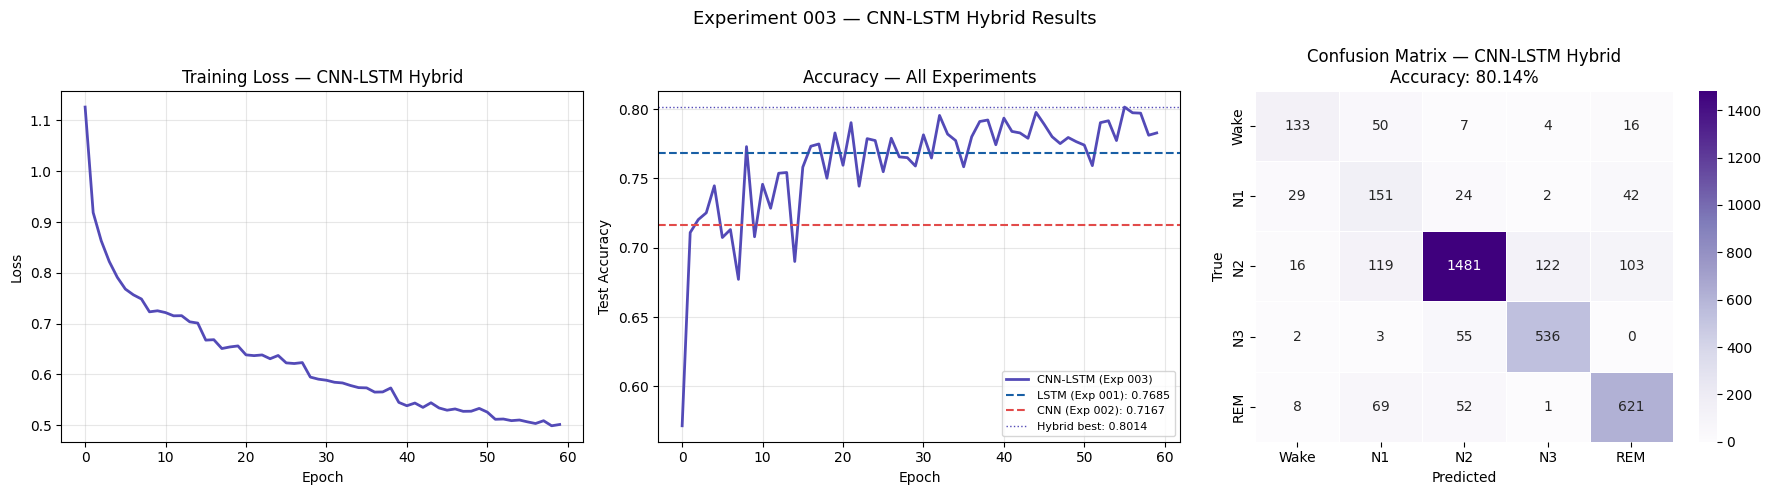

 Plot saved


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Loss curve ────────────────────────────────────────────
axes[0].plot(losses, color='#534AB7', linewidth=2)
axes[0].set_title('Training Loss — CNN-LSTM Hybrid')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

# ── Accuracy curves with baselines ────────────────────────
axes[1].plot(accs, color='#534AB7', linewidth=2,
             label='CNN-LSTM (Exp 003)')
axes[1].axhline(
    y=BASELINE['exp001_lstm']['accuracy'],
    color='#185FA5', linestyle='--', linewidth=1.5,
    label=f"LSTM (Exp 001): {BASELINE['exp001_lstm']['accuracy']:.4f}"
)
axes[1].axhline(
    y=BASELINE['exp002_cnn']['accuracy'],
    color='#E24B4A', linestyle='--', linewidth=1.5,
    label=f"CNN (Exp 002): {BASELINE['exp002_cnn']['accuracy']:.4f}"
)
axes[1].axhline(
    y=best_acc, color='#534AB7',
    linestyle=':', linewidth=1,
    label=f'Hybrid best: {best_acc:.4f}'
)
axes[1].set_title('Accuracy — All Experiments')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# ── Confusion matrix ──────────────────────────────────────
cm = confusion_matrix(final_true, final_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=STAGE_NAMES,
    yticklabels=STAGE_NAMES,
    ax=axes[2], linewidths=0.5
)
axes[2].set_title(
    f'Confusion Matrix — CNN-LSTM Hybrid\n'
    f'Accuracy: {final_acc*100:.2f}%'
)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.suptitle('Experiment 003 — CNN-LSTM Hybrid Results',
             fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_DIR, 'exp003_training_results.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Plot saved")

## Conclusions

### Did CNN-LSTM beat both baselines?
(Fill in after running)

### Architecture analysis
The CNN component processes each 3-second window 
independently, learning local frequency patterns.
The LSTM then reads the sequence of 10 CNN feature 
vectors, learning how brain states transition over 
the full 30-second epoch.

### Key finding
(Fill in after running — did spatial + temporal beat temporal alone?)

### Implication for Project 07
(Fill in based on REM recall result)

### Next experiment
Experiment 004 — Add attention mechanism to CNN-LSTM.
Self-attention over the 10 CNN windows lets the model 
weight which windows are most informative for classification.
This is the DeepSleepNet → AttnSleep progression.

In [9]:
results_003 = {
    'experiment':   '003',
    'name':         'CNN-LSTM Hybrid',
    'date':         datetime.now().strftime('%Y-%m-%d'),
    'model':        'CNNLSTMSleepClassifier',
    'config': {
        'n_windows':   10,
        'window_size': 300,
        'cnn_filters': [32, 64, 128],
        'lstm_hidden': 128,
        'lstm_layers': 2,
        'bidirectional': True,
        'dropout':     0.3,
        'optimizer':   'Adam',
        'lr':          0.001,
        'epochs':      EPOCHS,
        'batch_size':  64,
    },
    'results': {
        'accuracy':     round(float(final_acc), 4),
        'rem_recall':   round(float(rem_recall), 4),
    },
    'vs_baselines': {
        'vs_exp001_lstm': {
            'accuracy_delta': round(
                float(final_acc -
                      BASELINE['exp001_lstm']['accuracy']), 4),
            'rem_recall_delta': round(
                float(rem_recall -
                      BASELINE['exp001_lstm']['rem_recall']), 4),
        },
        'vs_exp002_cnn': {
            'accuracy_delta': round(
                float(final_acc -
                      BASELINE['exp002_cnn']['accuracy']), 4),
            'rem_recall_delta': round(
                float(rem_recall -
                      BASELINE['exp002_cnn']['rem_recall']), 4),
        }
    }
}

path = os.path.join(LOGS_DIR, 'experiment_003_results.json')
with open(path, 'w') as f:
    json.dump(results_003, f, indent=2)

print(f" Results saved to {path}")
print(f"\n=== Final Summary ===")
print(f"  Exp 001 LSTM:         {BASELINE['exp001_lstm']['accuracy']:.4f}")
print(f"  Exp 002 CNN:          {BASELINE['exp002_cnn']['accuracy']:.4f}")
print(f"  Exp 003 CNN-LSTM:     {final_acc:.4f}")
delta = final_acc - BASELINE['exp001_lstm']['accuracy']
arrow = "↑" if delta > 0 else "↓"
print(f"  vs LSTM baseline:     {arrow}{abs(delta):.4f}")
print(f"\n  REM recall exp001:    {BASELINE['exp001_lstm']['rem_recall']:.4f}")
print(f"  REM recall exp003:    {rem_recall:.4f}")

 Results saved to C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\logs\experiment_003_results.json

=== Final Summary ===
  Exp 001 LSTM:         0.7685
  Exp 002 CNN:          0.7167
  Exp 003 CNN-LSTM:     0.8014
  vs LSTM baseline:     ↑0.0329

  REM recall exp001:    0.8400
  REM recall exp003:    0.8269
